In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score, auc
from sklearn.preprocessing import LabelEncoder

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [58]:
df=pd.read_csv("/content/drive/My Drive/Colab Notebooks/Machine Learning/unique_tech_classroom_air_quality.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                500 non-null    object 
 1   school_period            500 non-null    object 
 2   student_count_estimated  500 non-null    int64  
 3   co2_ppm                  500 non-null    float64
 4   pm25_ugm3                500 non-null    float64
 5   temperature_c            500 non-null    float64
 6   humidity_pct             500 non-null    float64
 7   robot_x_pos              500 non-null    float64
 8   robot_y_pos              500 non-null    float64
 9   ventilation_decision     500 non-null    object 
 10  air_quality_label        500 non-null    object 
dtypes: float64(6), int64(1), object(4)
memory usage: 43.1+ KB


In [60]:
df.shape

(500, 11)

In [61]:
df.describe()

,student_count_estimated,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,robot_x_pos,robot_y_pos
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,11.184000,619.266400,8.439960,20.48980,44.594400,2.005800,1.990000
std,9.446301,155.967082,2.718404,0.19191,3.057506,1.415639,1.420781
min,0.000000,432.200000,4.400000,20.20000,41.300000,0.000000,0.000000
25%,3.000000,493.825000,6.170000,20.40000,41.800000,0.600000,0.600000
50%,7.000000,529.200000,7.080000,20.50000,42.800000,2.050000,2.000000
75%,22.000000,801.425000,11.512500,20.50000,47.800000,3.400000,3.400000
max,27.000000,893.000000,14.500000,21.00000,49.700000,4.000000,4.000000


In [62]:
df.isnull().sum()

,0
timestamp,0
school_period,0
student_count_estimated,0
co2_ppm,0
pm25_ugm3,0
temperature_c,0
humidity_pct,0
robot_x_pos,0
robot_y_pos,0
ventilation_decision,0


In [63]:
print("Number of duplicated records: ",df.duplicated().sum())

Number of duplicated records:  0


In [64]:
df.head()

,timestamp,school_period,student_count_estimated,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,robot_x_pos,robot_y_pos,ventilation_decision,air_quality_label
0,2025-11-12 08:00:00,Morning Entry,11,442.1,5.16,21.0,45.0,2.0,4.0,IDLE,Good
1,2025-11-12 08:01:42,Morning Entry,6,444.6,5.08,21.0,44.8,2.2,4.0,IDLE,Good
2,2025-11-12 08:03:24,Morning Entry,11,466.9,5.93,21.0,44.7,2.7,3.8,IDLE,Good
3,2025-11-12 08:05:06,Morning Entry,6,483.6,5.49,21.0,44.6,2.7,3.8,IDLE,Good
4,2025-11-12 08:06:48,Morning Entry,16,520.6,6.25,21.0,44.7,3.2,3.9,IDLE,Good


In [65]:
#feature summary
numerical_features=df.select_dtypes(include=['int64','float64']).columns
categorical_features=df.select_dtypes(include=['object']).columns
print("Feature Summary")
print("Numerical features:")
for col in numerical_features:
    print("-",col)
print("Categorical features: ")
for col in categorical_features:
    print("-",col)

Feature Summary
Numerical features:
- student_count_estimated
- co2_ppm
- pm25_ugm3
- temperature_c
- humidity_pct
- robot_x_pos
- robot_y_pos
Categorical features: 
- timestamp
- school_period
- ventilation_decision
- air_quality_label


In [66]:
df.columns = df.columns.str.strip()
df = df.drop(columns='timestamp', errors='ignore')
le = LabelEncoder()
df['air_quality_label'] = le.fit_transform(df['air_quality_label'])
df['school_period'] = le.fit_transform(df['school_period'])
df['ventilation_decision'] = le.fit_transform(df['ventilation_decision'])

In [67]:
# Separate features and target
x=df.iloc[:,:-1]
y=df.iloc[:,-1]
print("Features (X) and target (y) separated successfully")

Features (X) and target (y) separated successfully


In [68]:
# Split the dataset into training and testing sets
x_train,x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
print("Dataset split into training and testing sets")

Dataset split into training and testing sets


In [69]:
print("Dataset successfully split into training and testing sets")
print("Training set size:", x_train.shape)
print("Testing set size:", x_test.shape)

Dataset successfully split into training and testing sets
Training set size: (400, 9)
Testing set size: (100, 9)


In [70]:
#model building
model=DecisionTreeClassifier(criterion='entropy')
model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy')

In [71]:
#predictions on test data
y_pred=model.predict(x_test)

In [72]:
#evaluation metrics
confusion_matrix(y_test,y_pred)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

[[67  0]
 [ 0 33]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        67
           1       1.00      1.00      1.00        33

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

1.0


In [73]:
# Training Accuracy
train_accuracy = model.score(x_train, y_train)
# Testing Accuracy
test_accuracy = model.score(x_test, y_test)
print("Training Accuracy: {:.2f}%".format(train_accuracy * 100))
print("Testing Accuracy: {:.2f}%".format(test_accuracy * 100))

Training Accuracy: 100.00%
Testing Accuracy: 100.00%


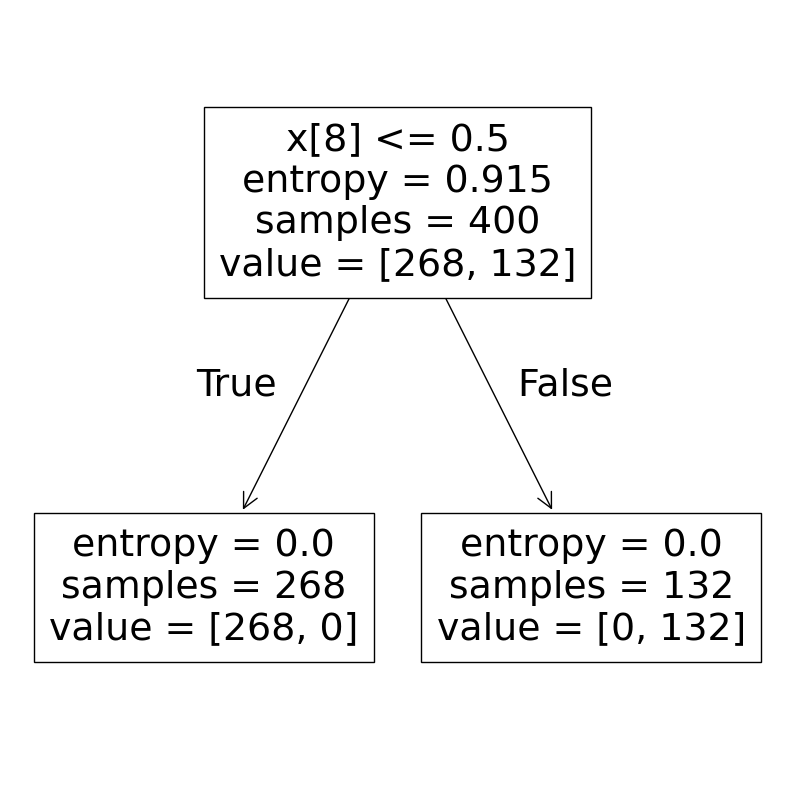

In [74]:
from sklearn import tree
plt.figure(figsize=(10,10))
tree.plot_tree(model)
plt.show()

In [75]:
#auc_roc_score
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(1.0)

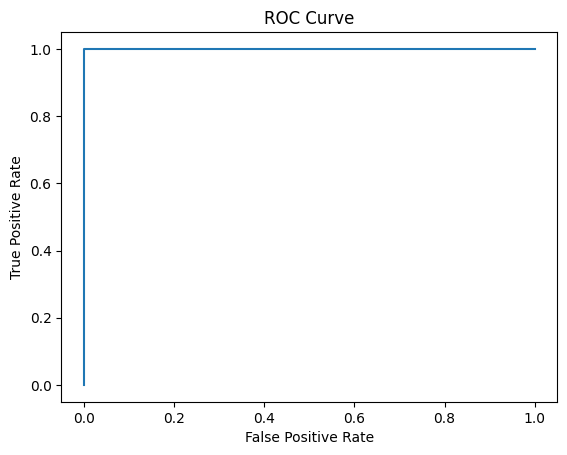

In [76]:
#roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()